# Faza 1 — Preț uree: baseline naive, LSTM și BiLSTM

Pipeline: încărcare date → ffill → naive forecast → secvențe scalate → **UreaLSTM** → **UreaBiLSTM**.

**Rulează celulele Python în ordine.** Kernel necesar: **Python (conda base)**.

In [1]:
import numpy as np
import sys
print("Python:", sys.executable)

import pandas as pd
print("pandas", pd.__version__)

raw = pd.read_excel(
    "data/CMO-Historical-Data-Monthly.xlsx",
    sheet_name="Monthly Prices",
    skiprows=6,
)

df = raw[["Unnamed: 0", "UREA_EE_BULK"]].rename(
    columns={"Unnamed: 0": "Date", "UREA_EE_BULK": "Urea_Price"}
)

df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%YM%m")
df = df.set_index("Date")
df["Urea_Price"] = pd.to_numeric(df["Urea_Price"], errors="coerce")

print("\nPrimele 5 rânduri:")
print(df.head())

print("\nValori lipsă:")
print(df.isna().sum())

Python: /opt/miniconda3/bin/python


pandas 3.0.2



Primele 5 rânduri:
            Urea_Price
Date                  
1960-01-01       42.25
1960-02-01       42.25
1960-03-01       42.25
1960-04-01       42.25
1960-05-01       42.25

Valori lipsă:
Urea_Price    0
dtype: int64


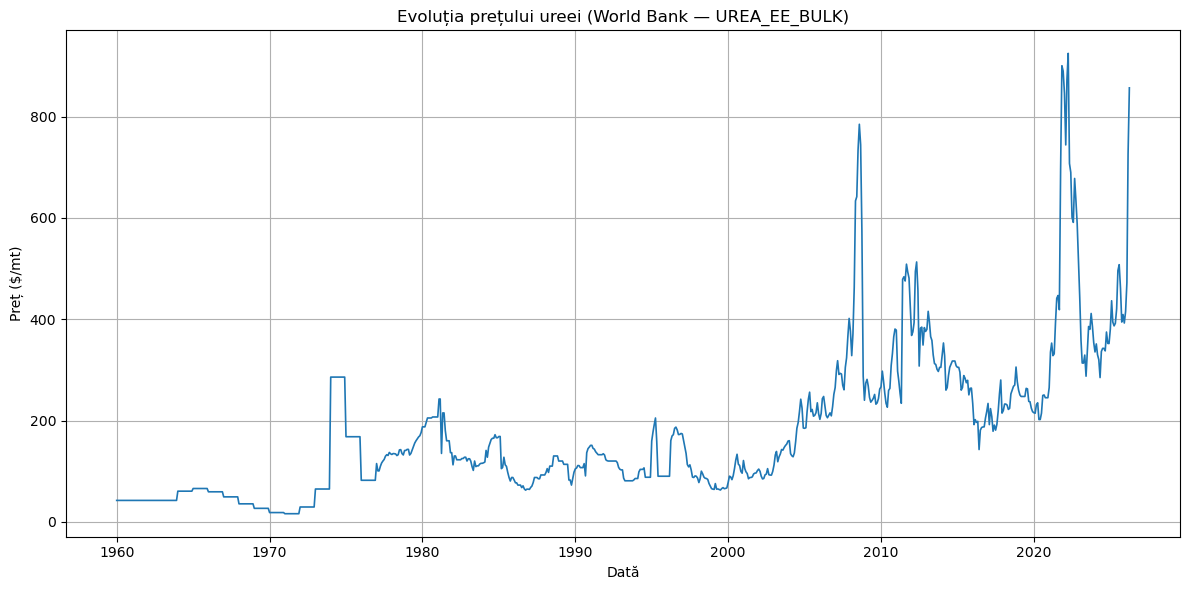

Metrici Naive Forecast (pe întreaga serie, după ffill):
  MAE  = 13.5306
  RMSE = 33.0590
  MAPE = 5.87%


In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Acopera valorile lipsa propagand ultima observatie valida inainte
df = df.ffill()

# Grafic serie temporala
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Urea_Price"], linewidth=1.2)
plt.title("Evoluția prețului ureei (World Bank — UREA_EE_BULK)")
plt.xlabel("Dată")
plt.ylabel("Preț ($/mt)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Baseline Naive Forecast: predictia pentru luna t = pretul din luna t-1
df["Naive_Forecast"] = df["Urea_Price"].shift(1)

# Comparam doar randurile unde exista ambele valori (shift elimina primul rand)
eval_df = df.dropna(subset=["Naive_Forecast"])
y_true = eval_df["Urea_Price"]
y_pred = eval_df["Naive_Forecast"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Metrici Naive Forecast (pe întreaga serie, după ffill):")
print(f"  MAE  = {mae:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  MAPE = {mape:.2f}%")

### Forward fill (`ffill`) și rețele neuronale

Seriile pentru LSTM/BiLSTM necesită **secvențe continue**, fără `NaN`. `ffill()` propagă ultima valoare cunoscută în viitor, astfel încât fiecare pas temporal are un număr valid. Fără această etapă, ferestrele de intrare ar conține goluri, iar antrenarea s-ar opri sau ar produce gradienți invalizi. Metoda păstrează structura calendaristică (nu șterge luni), dar **nu creează informație nouă** — doar completează lipsurile cu ultima observație.

> Pe acest set de date, după `pd.to_numeric`, nu există valori lipsă (`NaN = 0`); `ffill()` este totuși păstrat ca pas standard al pipeline-ului.

### Formule — MAE și RMSE

Pentru $n$ perechi $(y_i, \hat{y}_i)$ (preț real vs. predicție naive):

**MAE** (Mean Absolute Error):

$$\mathrm{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**RMSE** (Root Mean Squared Error):

$$\mathrm{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

**MAPE** (folosit la afișare): media erorilor procentuale absolute, $\frac{100}{n}\sum_i \left|\frac{y_i - \hat{y}_i}{y_i}\right|$.

RMSE penalizează mai puternic erorile mari; MAE este mai robustă la outlieri.

Baseline-ul naive (lag 1) oferă un **plan de referință**. Metricile de pe întreaga serie (celula anterioară) sunt utile ca overview istoric; **comparația corectă cu LSTM/BiLSTM** se face pe **aceeași fereastră de test** (ultimele ~20% din serie), calculată în celula de pregătire a secvențelor.

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

LOOK_BACK = 12
TRAIN_RATIO = 0.80

# Serie univariata (coloana -> vector 2D pentru sklearn)
series = df[["Urea_Price"]].values.astype(np.float32)
n = len(series)
train_end = int(n * TRAIN_RATIO)

# Scalare: fit doar pe perioada de antrenare (evita data leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(series[:train_end])
series_scaled = scaler.transform(series).astype(np.float32)


def create_sequences(data, look_back=12):
    """Transformă seria scalată în perechi (X, y): X = ultimele look_back luni, y = luna următoare."""
    X, y, target_idx = [], [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back : i])
        y.append(data[i])
        target_idx.append(i)
    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(target_idx, dtype=np.int64),
    )


X, y, target_idx = create_sequences(series_scaled, look_back=LOOK_BACK)

# Impartire cronologica: antrenare = tinte in primii 80% din serie
train_mask = target_idx < train_end
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[~train_mask], y[~train_mask]

# Format 3D pentru LSTM: (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], LOOK_BACK, 1)
X_test = X_test.reshape(X_test.shape[0], LOOK_BACK, 1)

print("Dimensiuni seturi:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")
print(f"\nAntrenare: primele {train_end} luni | Test: ultimele {n - train_end} luni")

# Naive baseline pe aceeași fereastră de test ca LSTM/BiLSTM
test_target_idx = target_idx[~train_mask]
y_test_real = series[test_target_idx].reshape(-1, 1).ravel()
y_pred_naive_test = series[test_target_idx - 1].reshape(-1, 1).ravel()

mae_naive_test = mean_absolute_error(y_test_real, y_pred_naive_test)
rmse_naive_test = np.sqrt(mean_squared_error(y_test_real, y_pred_naive_test))
mape_naive_test = np.mean(np.abs((y_test_real - y_pred_naive_test) / y_test_real)) * 100

print("\nMetrici Naive (aceeași fereastră de test):")
print(f"  MAE  = {mae_naive_test:.4f}")
print(f"  RMSE = {rmse_naive_test:.4f}")
print(f"  MAPE = {mape_naive_test:.2f}%")

Dimensiuni seturi:
  X_train: (624, 12, 1)
  y_train: (624, 1)
  X_test:  (160, 12, 1)
  y_test:  (160, 1)

Antrenare: primele 636 luni | Test: ultimele 160 luni

Metrici Naive (aceeași fereastră de test):
  MAE  = 28.8682
  RMSE = 50.8068
  MAPE = 7.54%


### Tensor 3D pentru LSTM

Un LSTM așteaptă intrări de forma **(samples, time_steps, features)**:

| Axă | Semnificație | Avem |
|-----|----------------|--------|
| **samples** | Câte ferestre de antrenare/test | ex. 624 / 160 |
| **time_steps** | Lungimea istoricului (`look_back`) | 12 luni |
| **features** | Variabile la fiecare pas temporal | 1 (`Urea_Price`) |

După `create_sequences`, `X` are forma `(N, 12, 1)` — deja 12 pași cu 1 caracteristică pe pas. `reshape(..., LOOK_BACK, 1)` fixează explicit al treilea ax (features), cerut de API-urile Keras/PyTorch pentru serii univariate.

Fiecare sample: tensor $X_t \in \mathbb{R}^{12 \times 1}$ (prețuri scalate din lunile $t-12,\ldots,t-1$) → țintă $y_t$ (prețul din luna $t$).

**Notă scalare:** `MinMaxScaler` este antrenat doar pe primele 80% din serie. Valorile din test pot depăși maximul din train (ex. vârful din 2021–2022), deci după `transform` pot apărea valori **peste 1.0** — nu sunt erori, ci reflectă prețuri mai mari decât orice valoare văzută la antrenare.

In [4]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# 1. Numpy -> tensori PyTorch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

print("Device:", device)
print("X_train_t:", X_train_t.shape, "| y_train_t:", y_train_t.shape)


# 2. Arhitectura UreaLSTM: LSTM + Linear
class UreaLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_step = lstm_out[:, -1, :]
        return self.linear(last_step)


# 3. Model, loss, optimizer
HIDDEN_SIZE = 32
EPOCHS = 600
LEARNING_RATE = 0.0005

model = UreaLSTM(input_size=1, hidden_size=HIDDEN_SIZE).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 4. Bucla de antrenare ( epochs )
train_losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t.view(-1, 1))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoca {epoch + 1}/{EPOCHS} | MSE loss: {loss.item():.6f}")

# 5. Predictii pe setul de test
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).cpu().numpy()

# 6. Inverse transform (valori reale $/mt)
y_pred_real = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# 7. Metrici (y_test_real calculat in celula de secvente)
mae_lstm = mean_absolute_error(y_test_real, y_pred_real)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mape_lstm = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print("\nMetrici LSTM (set de test, preturi reale):")
print(f"  MAE  = {mae_lstm:.4f}")
print(f"  RMSE = {rmse_lstm:.4f}")
print(f"  MAPE = {mape_lstm:.2f}%")

print("\nComparatie cu Naive (aceeasi fereastra de test):")
print(f"  Naive MAPE = {mape_naive_test:.2f}% | LSTM MAPE = {mape_lstm:.2f}%")

Device: cpu
X_train_t: torch.Size([624, 12, 1]) | y_train_t: torch.Size([624, 1])


Epoca 1/600 | MSE loss: 0.057340
Epoca 10/600 | MSE loss: 0.042644
Epoca 20/600 | MSE loss: 0.031043


Epoca 30/600 | MSE loss: 0.023321
Epoca 40/600 | MSE loss: 0.018807
Epoca 50/600 | MSE loss: 0.016927


Epoca 60/600 | MSE loss: 0.016420
Epoca 70/600 | MSE loss: 0.015877


Epoca 80/600 | MSE loss: 0.015172
Epoca 90/600 | MSE loss: 0.014445


...

Epoca 460/600 | MSE loss: 0.002975
Epoca 470/600 | MSE loss: 0.002927
Epoca 480/600 | MSE loss: 0.002880


Epoca 490/600 | MSE loss: 0.002834
Epoca 500/600 | MSE loss: 0.002788
Epoca 510/600 | MSE loss: 0.002744


Epoca 520/600 | MSE loss: 0.002701
Epoca 530/600 | MSE loss: 0.002660
Epoca 540/600 | MSE loss: 0.002621


Epoca 550/600 | MSE loss: 0.002583
Epoca 560/600 | MSE loss: 0.002547
Epoca 570/600 | MSE loss: 0.002512


Epoca 580/600 | MSE loss: 0.002478
Epoca 590/600 | MSE loss: 0.002444
Epoca 600/600 | MSE loss: 0.002409

Metrici LSTM (set de test, preturi reale):
  MAE  = 45.1932
  RMSE = 81.2788
  MAPE = 11.13%

Comparatie cu Naive (aceeasi fereastra de test):
  Naive MAPE = 7.54% | LSTM MAPE = 11.13%


### Arhitectura `UreaLSTM`

```
Intrare X: (batch, 12, 1)  — 12 luni de pret scalat
        |
   nn.LSTM (hidden=32)
        |
  ultimul pas temporal (t-1)
        |
   nn.Linear -> 1 valoare
        |
 Iesire: pretul lunii t (scalat)
```

- **nn.LSTM** — memoreaza dependente pe termen lung in cele 12 luni; la fiecare pas primeste un pret si actualizeaza starea interna (hidden + cell).
- **Ultimul pas** (`lstm_out[:, -1, :]`) — folosim doar reprezentarea dupa ce a „vazut” toate cele 12 luni.
- **nn.Linear** — mapeaza vectorul de 32 neuroni la **un singur numar**: predictia pentru luna urmatoare.
- **nn.MSELoss** — penalizeaza erorile mari la patrat (diferenta intre predictie si y_train).
- **Adam** — actualizeaza ponderile modelului cu un pas adaptiv de gradient.

### Pasii din bucla de antrenare

Inainte de bucla: **`model.train()`** — activeaza modul antrenare (ex. dropout daca ar exista).

La **fiecare epoca**:

1. **`optimizer.zero_grad()`** — sterge gradientii vechi de la epoca anterioara.
2. **`predictions = model(X_train_t)`** — forward pass pe toate exemplele de train.
3. **`loss = criterion(predictions, y_train_t.view(-1, 1))`** — MSE fata de pretul real (scalat); `.view(-1, 1)` aliniaza formele tensorilor.
4. **`loss.backward()`** — backpropagation: calculeaza cum trebuie schimbate ponderile.
5. **`optimizer.step()`** — aplica actualizarea ponderilor.

Dupa 50 epoci: **`model.eval()`** + **`torch.no_grad()`** pe test — fara invatare, doar predictie. Apoi **`inverse_transform`** aduce predictiile in dolari/mt pentru metrici interpretabile.

In [5]:
# UreaBiLSTM — aceiasi tensori X_train_t, y_train_t, X_test_t (din celula LSTM)

torch.manual_seed(SEED)


class UreaBiLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )
        self.linear = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        forward_hidden = h_n[-2, :, :]
        backward_hidden = h_n[-1, :, :]
        hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        return self.linear(hidden)


model_bilstm = UreaBiLSTM(input_size=1, hidden_size=HIDDEN_SIZE).to(device)
criterion_bilstm = nn.MSELoss()
optimizer_bilstm = torch.optim.Adam(model_bilstm.parameters(), lr=LEARNING_RATE)

train_losses_bilstm = []
model_bilstm.train()
for epoch in range(EPOCHS):
    optimizer_bilstm.zero_grad()
    predictions = model_bilstm(X_train_t)
    loss = criterion_bilstm(predictions, y_train_t.view(-1, 1))
    loss.backward()
    optimizer_bilstm.step()
    train_losses_bilstm.append(loss.item())
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoca {epoch + 1}/{EPOCHS} | MSE loss: {loss.item():.6f}")

model_bilstm.eval()
with torch.no_grad():
    y_pred_bilstm_scaled = model_bilstm(X_test_t).cpu().numpy()

y_pred_bilstm_scaled_2d = y_pred_bilstm_scaled.reshape(-1, 1)
y_pred_bilstm_real = scaler.inverse_transform(y_pred_bilstm_scaled_2d).ravel()

mae_bilstm = mean_absolute_error(y_test_real, y_pred_bilstm_real)
rmse_bilstm = np.sqrt(mean_squared_error(y_test_real, y_pred_bilstm_real))
mape_bilstm = np.mean(np.abs((y_test_real - y_pred_bilstm_real) / y_test_real)) * 100

print("\nMetrici BiLSTM (set de test, preturi reale):")
print(f"  MAE  = {mae_bilstm:.4f}")
print(f"  RMSE = {rmse_bilstm:.4f}")
print(f"  MAPE = {mape_bilstm:.2f}%")

print("\nComparatie cu Naive (aceeasi fereastra de test):")
print(f"  Naive MAPE = {mape_naive_test:.2f}% | BiLSTM MAPE = {mape_bilstm:.2f}%")

Epoca 1/600 | MSE loss: 0.045464
Epoca 10/600 | MSE loss: 0.028894


Epoca 20/600 | MSE loss: 0.020202
Epoca 30/600 | MSE loss: 0.018630


Epoca 40/600 | MSE loss: 0.018175
Epoca 50/600 | MSE loss: 0.017164


Epoca 60/600 | MSE loss: 0.016397
Epoca 70/600 | MSE loss: 0.015574


Epoca 80/600 | MSE loss: 0.014646
Epoca 90/600 | MSE loss: 0.013595


...

Epoca 530/600 | MSE loss: 0.002139
Epoca 540/600 | MSE loss: 0.002097


Epoca 550/600 | MSE loss: 0.002054


Epoca 560/600 | MSE loss: 0.002013
Epoca 570/600 | MSE loss: 0.001972


Epoca 580/600 | MSE loss: 0.001933
Epoca 590/600 | MSE loss: 0.001894


Epoca 600/600 | MSE loss: 0.001857

Metrici BiLSTM (set de test, preturi reale):
  MAE  = 43.7457
  RMSE = 78.7131
  MAPE = 10.80%

Comparatie cu Naive (aceeasi fereastra de test):
  Naive MAPE = 7.54% | BiLSTM MAPE = 10.80%


### De ce `nn.Linear(hidden_size * 2, 1)` la BiLSTM?

La `bidirectional=True`, PyTorch ruleaza **doua** LSTM-uri in paralel:

- unul **forward** (t = 1 → 12), care citeste secventa in ordine cronologica;
- unul **backward** (t = 12 → 1), care o citeste in sens invers.

La fiecare pas temporal $t$, output-ul nu mai este un singur vector $\mathbf{h}_t \in \mathbb{R}^{d}$ (cu $d = \texttt{hidden\_size}$), ci **concatenarea** celor doua directii:

$$
\mathbf{h}_t^{\text{bi}} = \left[\,\overrightarrow{\mathbf{h}}_t \;\|\; \overleftarrow{\mathbf{h}}_t\,\right] \in \mathbb{R}^{2d}
$$

unde $\overrightarrow{\mathbf{h}}_t$ este starea hidden a LSTM-ului forward, iar $\overleftarrow{\mathbf{h}}_t$ starea hidden a celui backward.

La ultimul pas ($t = 12$), folosim $\mathbf{h}_{12}^{\text{bi}} \in \mathbb{R}^{64}$ (pentru $d=32$). Stratul liniar trebuie sa accepte exact aceasta dimensiune:

$$
\hat{y} = \mathbf{w}^\top \mathbf{h}_{12}^{\text{bi}} + b, \quad \mathbf{w} \in \mathbb{R}^{2d}
$$

De aceea `nn.Linear(32, 1)` devine `nn.Linear(32 * 2, 1)` — nu pentru ca avem mai multi neuroni LSTM, ci pentru ca **fiecare directie contribuie cu $d$ features**, iar acestea sunt puse cap-coada (concatenate), nu insumate.

In [7]:
# Acuratețe direcțională + tabel sumar (Naive vs LSTM vs BiLSTM)
# Foloseste seriile deja calculate in celulele de evaluare LSTM/BiLSTM de mai sus.

import pandas as pd


def directional_accuracy(actual, predicted):
    """Procentul de pasi in care sign(pred_t - pred_{t-1}) == sign(actual_t - actual_{t-1})."""
    actual_diff = np.diff(actual)
    predicted_diff = np.diff(predicted)
    correct = np.sign(actual_diff) == np.sign(predicted_diff)
    return np.mean(correct) * 100


da_naive = directional_accuracy(y_test_real, y_pred_naive_test)
da_lstm = directional_accuracy(y_test_real, y_pred_real)
da_bilstm = directional_accuracy(y_test_real, y_pred_bilstm_real)

summary_table = pd.DataFrame(
    [
        {
            "Model": "Naive",
            "MAE": mae_naive_test,
            "RMSE": rmse_naive_test,
            "MAPE": mape_naive_test,
            "Directional Accuracy (%)": da_naive,
        },
        {
            "Model": "LSTM",
            "MAE": mae_lstm,
            "RMSE": rmse_lstm,
            "MAPE": mape_lstm,
            "Directional Accuracy (%)": da_lstm,
        },
        {
            "Model": "BiLSTM",
            "MAE": mae_bilstm,
            "RMSE": rmse_bilstm,
            "MAPE": mape_bilstm,
            "Directional Accuracy (%)": da_bilstm,
        },
    ]
).set_index("Model")

print("=" * 70)
print("TABEL SUMAR — Naive vs LSTM vs BiLSTM (set de test)")
print("=" * 70)
print(summary_table.round(4).to_string())

summary_table

TABEL SUMAR — Naive vs LSTM vs BiLSTM (set de test)
            MAE     RMSE     MAPE  Directional Accuracy (%)
Model                                                      
Naive   28.8682  50.8068   7.5365                   55.3459
LSTM    45.1932  81.2788  11.1272                   46.5409
BiLSTM  43.7457  78.7131  10.7960                   48.4277


,MAE,RMSE,MAPE,Directional Accuracy (%)
Model,,,,
Naive,28.868168,50.806830,7.536476,55.345912
LSTM,45.193180,81.278817,11.127243,46.540881
BiLSTM,43.745731,78.713052,10.795959,48.427673


In [8]:
# Salvare modele si scaler (checkpoint Faza 1 -> necesar pentru Faza 2 / Streamlit)

import os
import joblib

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

lstm_path = os.path.join(MODELS_DIR, "lstm_urea_v1.pt")
bilstm_path = os.path.join(MODELS_DIR, "bilstm_urea_v1.pt")
scaler_path = os.path.join(MODELS_DIR, "scaler_urea_v1.pkl")

torch.save(model.state_dict(), lstm_path)
torch.save(model_bilstm.state_dict(), bilstm_path)
joblib.dump(scaler, scaler_path)

print("Fisiere salvate in:", os.path.abspath(MODELS_DIR))
print("-", lstm_path)
print("-", bilstm_path)
print("-", scaler_path)

Fisiere salvate in: /Users/claudiupanainte/Desktop/Disertatie-ML-Agricultură/models
- models/lstm_urea_v1.pt
- models/bilstm_urea_v1.pt
- models/scaler_urea_v1.pkl


# Faza 2 — Model multivariat (Pink Sheet + EXUSEU, log-returns)

Extensie a pipeline-ului de mai sus. **Nicio celulă din Faza 1 nu este modificată** — celulele de jos refolosesc `UreaLSTM`, `UreaBiLSTM`, funcțiile de metrici (`mean_absolute_error`, `mean_squared_error`) și convențiile deja stabilite (split cronologic 80/20, scaler antrenat doar pe train).

Pipeline Faza 2: încărcare Pink Sheet (coloane suplimentare) + EXUSEU → merge (inner join) → ffill → log-returns → ferestre multivariate (`LOOK_BACK` ∈ {6, 12, 24}) → `UreaLSTM` / `UreaBiLSTM` cu early stopping → reconstrucție preț din log-return → evaluare vs. baseline naiv → tabel sumar.

In [9]:
# ============================================================
# FAZA 2 — 1. DATA MERGE (Pink Sheet extins + EXUSEU)
# ============================================================

import pandas as pd
import numpy as np

PINK_SHEET_PATH = "data/CMO-Historical-Data-Monthly.xlsx"

# --- 1a. Pink Sheet, foaia "Monthly Prices" (aceeasi foaie ca in Faza 1) ---
raw_prices_p2 = pd.read_excel(PINK_SHEET_PATH, sheet_name="Monthly Prices", skiprows=6)

print("Coloane disponibile in foaia 'Monthly Prices':")
print(list(raw_prices_p2.columns))

requested_price_cols = [
    "UREA_EE_BULK",
    "NGAS_US",
    "NGAS_EUR",
    "CRUDE_PETRO",
    "iFERTILIZERS",
    "MAIZE",
    "WHEAT_US_SRW",
]
found_price_cols = [c for c in requested_price_cols if c in raw_prices_p2.columns]
missing_price_cols = [c for c in requested_price_cols if c not in raw_prices_p2.columns]

print("\nColoane gasite EXACT in 'Monthly Prices':", found_price_cols)
if missing_price_cols:
    print("Coloane NEGASITE in 'Monthly Prices':", missing_price_cols)

price_df = raw_prices_p2[["Unnamed: 0"] + found_price_cols].rename(columns={"Unnamed: 0": "Date"})
price_df["Date"] = pd.to_datetime(price_df["Date"].astype(str), format="%YM%m")
price_df = price_df.set_index("Date")
for c in found_price_cols:
    price_df[c] = pd.to_numeric(price_df[c], errors="coerce")

# --- 1b. iFERTILIZERS nu exista ca atare in "Monthly Prices" (vezi lista de mai sus) ---
# Este disponibil in acelasi fisier Excel, pe foaia "Monthly Indices", ca subindicele
# de fertilizatori (afisat acolo drept "Fertilizers **" / cod "iFERTILIZERS").
if "iFERTILIZERS" in missing_price_cols:
    print("\n'iFERTILIZERS' nu exista in foaia 'Monthly Prices'.")
    print("Se preia din acelasi fisier Excel, foaia 'Monthly Indices' (subindice de fertilizatori).")

    raw_idx_p2 = pd.read_excel(PINK_SHEET_PATH, sheet_name="Monthly Indices", skiprows=6)
    fert_col_candidates = [c for c in raw_idx_p2.columns if "fertil" in str(c).lower()]
    print("Coloane candidate gasite in 'Monthly Indices':", fert_col_candidates)
    fert_col = fert_col_candidates[0]

    fert_df = raw_idx_p2[["Unnamed: 0", fert_col]].rename(
        columns={"Unnamed: 0": "Date", fert_col: "iFERTILIZERS"}
    )
    # Foaia "Monthly Indices" are cateva randuri de sub-antet (coduri/unitati) inainte
    # sa inceapa datele lunare -> pastram doar randurile in format "YYYYMxx".
    fert_df = fert_df[fert_df["Date"].astype(str).str.match(r"^\d{4}M\d{2}$", na=False)].copy()
    fert_df["Date"] = pd.to_datetime(fert_df["Date"].astype(str), format="%YM%m")
    fert_df = fert_df.set_index("Date")
    fert_df["iFERTILIZERS"] = pd.to_numeric(fert_df["iFERTILIZERS"], errors="coerce")

    price_df = price_df.join(fert_df, how="inner")
    found_price_cols = found_price_cols + ["iFERTILIZERS"]

print("\nColoane de pret/indice finale (din Pink Sheet) folosite in Faza 2:", found_price_cols)

# --- 1c. EXUSEU.csv (curs USD/EUR lunar) ---
exuseu = pd.read_csv("data/EXUSEU.csv").rename(columns={"observation_date": "Date"})
exuseu["Date"] = pd.to_datetime(exuseu["Date"])
exuseu = exuseu.set_index("Date")
exuseu["EXUSEU"] = pd.to_numeric(exuseu["EXUSEU"], errors="coerce")

# --- 1d. Merge (inner join pe Date) ---
df2 = price_df.join(exuseu, how="inner")

print("\nInterval de date dupa merge (inner join):", df2.index.min().date(), "->", df2.index.max().date())
print("Forma (shape) dupa merge:", df2.shape)

print("\nValori lipsa INAINTE de ffill:")
print(df2.isna().sum())

df2 = df2.ffill()

print("\nValori lipsa DUPA ffill:")
print(df2.isna().sum())

print("\nPrimele 5 randuri:")
print(df2.head())

Coloane disponibile in foaia 'Monthly Prices':
['Unnamed: 0', 'CRUDE_PETRO', 'CRUDE_BRENT', 'CRUDE_DUBAI', 'CRUDE_WTI', 'COAL_AUS', 'COAL_SAFRICA', 'NGAS_US', 'NGAS_EUR', 'NGAS_JP', 'iNATGAS', 'COCOA', 'COFFEE_ARABIC', 'COFFEE_ROBUS', 'TEA_AVG', 'TEA_COLOMBO', 'TEA_KOLKATA', 'TEA_MOMBASA', 'COCONUT_OIL', 'GRNUT', 'FISH_MEAL', 'GRNUT_OIL', 'PALM_OIL', 'PLMKRNL_OIL', 'SOYBEANS', 'SOYBEAN_OIL', 'SOYBEAN_MEAL', 'RAPESEED_OIL', 'SUNFLOWER_OIL', 'BARLEY', 'MAIZE', 'SORGHUM', 'RICE_05', 'RICE_25', 'RICE_A1', 'RICE_05_VNM', 'WHEAT_US_SRW', 'WHEAT_US_HRW', 'BANANA_EU', 'BANANA_US', 'ORANGE', 'BEEF', 'CHICKEN', 'LAMB', 'SHRIMP_MEX', 'SUGAR_EU', 'SUGAR_US', 'SUGAR_WLD', 'TOBAC_US', 'LOGS_CMR', 'LOGS_MYS', 'SAWNWD_CMR', 'SAWNWD_MYS', 'PLYWOOD', 'COTTON_A_INDX', 'RUBBER_TSR20', 'RUBBER1_MYSG', 'PHOSROCK', 'DAP', 'TSP', 'UREA_EE_BULK', 'POTASH', 'ALUMINUM', 'IRON_ORE', 'COPPER', 'LEAD', 'Tin', 'NICKEL', 'Zinc', 'GOLD', 'PLATINUM', 'SILVER']

Coloane gasite EXACT in 'Monthly Prices': ['UREA_EE_BULK',

In [10]:
# ============================================================
# FAZA 2 — 2. TARGET REFORMULATION (log-returns)
# ============================================================

ALL_LEVEL_COLS = found_price_cols + ["EXUSEU"]  # toate coloanele de pret/nivel continue

df2_logret = df2.copy()

LOGRET_FEATURE_COLS = []
for col in ALL_LEVEL_COLS:
    new_name = "urea_logret" if col == "UREA_EE_BULK" else f"{col}_logret"
    df2_logret[new_name] = np.log(df2_logret[col] / df2_logret[col].shift(1))
    LOGRET_FEATURE_COLS.append(new_name)

n_before_logret = len(df2_logret)
df2_logret = df2_logret.dropna(subset=["urea_logret"]).copy()
n_after_logret = len(df2_logret)

print(f"Randuri inainte de eliminarea primului NaN (log-return): {n_before_logret}")
print(f"Randuri dupa eliminare (primul rand, fara P_(t-1)): {n_after_logret}")

print("\nColoane de tip log-return (input model, target = 'urea_logret'):")
print(LOGRET_FEATURE_COLS)

print("\nColoane de pret ORIGINALE, pastrate pentru reconstructie ulterioara:")
print(ALL_LEVEL_COLS)

df2_logret[ALL_LEVEL_COLS + LOGRET_FEATURE_COLS].head()

Randuri inainte de eliminarea primului NaN (log-return): 328
Randuri dupa eliminare (primul rand, fara P_(t-1)): 327

Coloane de tip log-return (input model, target = 'urea_logret'):
['urea_logret', 'NGAS_US_logret', 'NGAS_EUR_logret', 'CRUDE_PETRO_logret', 'MAIZE_logret', 'WHEAT_US_SRW_logret', 'iFERTILIZERS_logret', 'EXUSEU_logret']

Coloane de pret ORIGINALE, pastrate pentru reconstructie ulterioara:
['UREA_EE_BULK', 'NGAS_US', 'NGAS_EUR', 'CRUDE_PETRO', 'MAIZE', 'WHEAT_US_SRW', 'iFERTILIZERS', 'EXUSEU']


,UREA_EE_BULK,NGAS_US,NGAS_EUR,CRUDE_PETRO,MAIZE,WHEAT_US_SRW,iFERTILIZERS,EXUSEU,urea_logret,NGAS_US_logret,NGAS_EUR_logret,CRUDE_PETRO_logret,MAIZE_logret,WHEAT_US_SRW_logret,iFERTILIZERS_logret,EXUSEU_logret
Date,,,,,,,,,,,,,,,,
1999-02-01,64.00,1.77,2.01,10.753333,94.19,94.96,31.808519,1.1203,-0.007782,-0.049597,-0.004963,-0.062192,-0.033923,-0.083019,0.035755,-0.034047
1999-03-01,75.50,1.79,1.95,13.166667,96.18,100.24,33.914497,1.0886,0.165250,0.011236,-0.030305,0.202473,0.020907,0.054112,0.064108,-0.028704
1999-04-01,64.50,2.15,1.87,15.866667,94.13,99.65,32.340269,1.0701,-0.157467,0.183252,-0.041891,0.186532,-0.021545,-0.005903,-0.047529,-0.017140
1999-05-01,64.90,2.25,1.89,16.063333,92.49,96.59,32.397514,1.0630,0.006182,0.045462,0.010638,0.012319,-0.017576,-0.031189,0.001769,-0.006657
1999-06-01,63.75,2.30,1.91,16.393333,93.65,92.94,32.162004,1.0377,-0.017878,0.021979,0.010526,0.020336,0.012464,-0.038521,-0.007296,-0.024088


In [11]:
# ============================================================
# FAZA 2 — 3. MULTIVARIATE DATASET PREPARATION
# ============================================================

from sklearn.preprocessing import MinMaxScaler

FEATURE_COLS = LOGRET_FEATURE_COLS  # toate seriile de log-return (targetul e inclus si ca feature autoregresiv)
TARGET_COL = "urea_logret"
TARGET_COL_IDX = FEATURE_COLS.index(TARGET_COL)
N_FEATURES = len(FEATURE_COLS)

LOOK_BACK_WINDOWS = [6, 12, 24]
TRAIN_RATIO_P2 = 0.80
VAL_RATIO_P2 = 0.10  # procent din SPLIT-ul de antrenare (nu din tot setul) — pt. early stopping

feature_matrix_full = df2_logret[FEATURE_COLS].values.astype(np.float32)
n_rows_p2 = len(df2_logret)
train_end_p2 = int(n_rows_p2 * TRAIN_RATIO_P2)

print(f"Numar total de randuri (dupa log-return): {n_rows_p2}")
print(f"Numar de caracteristici de intrare (input_size): {N_FEATURES} -> {FEATURE_COLS}")
print(f"Target: '{TARGET_COL}' (index coloana {TARGET_COL_IDX})")
print(f"Frontiera cronologica train/test (80/20): randul {train_end_p2}")


def create_multivariate_sequences(feature_data, target_data, look_back):
    """Generalizare a `create_sequences` din Faza 1 pentru mai multe caracteristici.

    X = ultimele `look_back` randuri (toate coloanele din `feature_data`);
    y = valoarea tinta (`target_data`) la pasul urmator t.
    """
    X, y, target_idx = [], [], []
    for i in range(look_back, len(feature_data)):
        X.append(feature_data[i - look_back : i])
        y.append(target_data[i])
        target_idx.append(i)
    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32).reshape(-1, 1),
        np.array(target_idx, dtype=np.int64),
    )


def inverse_transform_target(scaled_target_values, scaler, target_col_idx, n_features):
    """Inverseaza scalarea DOAR pentru coloana tinta, folosind un array 'dummy' de aceeasi latime
    ca cel pe care a fost antrenat scaler-ul (MinMaxScaler scaleaza fiecare coloana independent,
    deci valorile puse pe celelalte coloane nu influenteaza rezultatul pe coloana tinta)."""
    dummy = np.zeros((len(scaled_target_values), n_features), dtype=np.float32)
    dummy[:, target_col_idx] = np.asarray(scaled_target_values).ravel()
    return scaler.inverse_transform(dummy)[:, target_col_idx]


p2_datasets = {}

for look_back in LOOK_BACK_WINDOWS:
    # Scaler fit STRICT pe portiunea de train (evita data leakage), aplicat apoi pe toata seria
    scaler_p2 = MinMaxScaler(feature_range=(0, 1))
    scaler_p2.fit(feature_matrix_full[:train_end_p2])
    scaled_features_p2 = scaler_p2.transform(feature_matrix_full).astype(np.float32)
    scaled_target_p2 = scaled_features_p2[:, TARGET_COL_IDX]

    X_all, y_all, idx_all = create_multivariate_sequences(scaled_features_p2, scaled_target_p2, look_back)

    train_mask_p2 = idx_all < train_end_p2
    X_train_full = X_all[train_mask_p2]
    y_train_full = y_all[train_mask_p2]
    X_test_p2 = X_all[~train_mask_p2]
    y_test_p2 = y_all[~train_mask_p2]
    test_idx_p2 = idx_all[~train_mask_p2]

    # Validare = ultimele 10% din SPLIT-ul de antrenare (ordine cronologica pastrata, fara shuffle)
    n_train_full = len(X_train_full)
    n_val = max(1, int(round(n_train_full * VAL_RATIO_P2)))
    n_tr = n_train_full - n_val
    X_train_p2, y_train_p2 = X_train_full[:n_tr], y_train_full[:n_tr]
    X_val_p2, y_val_p2 = X_train_full[n_tr:], y_train_full[n_tr:]

    p2_datasets[look_back] = {
        "scaler": scaler_p2,
        "X_train": X_train_p2,
        "y_train": y_train_p2,
        "X_val": X_val_p2,
        "y_val": y_val_p2,
        "X_test": X_test_p2,
        "y_test": y_test_p2,
        "test_idx": test_idx_p2,
    }

    print(
        f"\nLOOK_BACK={look_back:>2} | X_train={X_train_p2.shape} X_val={X_val_p2.shape} "
        f"X_test={X_test_p2.shape} y_test={y_test_p2.shape}"
    )

Numar total de randuri (dupa log-return): 327
Numar de caracteristici de intrare (input_size): 8 -> ['urea_logret', 'NGAS_US_logret', 'NGAS_EUR_logret', 'CRUDE_PETRO_logret', 'MAIZE_logret', 'WHEAT_US_SRW_logret', 'iFERTILIZERS_logret', 'EXUSEU_logret']
Target: 'urea_logret' (index coloana 0)
Frontiera cronologica train/test (80/20): randul 261

LOOK_BACK= 6 | X_train=(229, 6, 8) X_val=(26, 6, 8) X_test=(66, 6, 8) y_test=(66, 1)

LOOK_BACK=12 | X_train=(224, 12, 8) X_val=(25, 12, 8) X_test=(66, 12, 8) y_test=(66, 1)

LOOK_BACK=24 | X_train=(213, 24, 8) X_val=(24, 24, 8) X_test=(66, 24, 8) y_test=(66, 1)


In [12]:
# ============================================================
# FAZA 2 — 4. MODEL TRAINING (multivariat, 3 ferestre x 2 arhitecturi = 6 antrenari)
# ============================================================
# Reutilizeaza UreaLSTM si UreaBiLSTM definite in Faza 1 (doar input_size este generalizat).

import copy

MAX_EPOCHS_P2 = 600          # aceeasi valoare ca in Faza 1 (plafon)
PATIENCE_P2 = 20              # early stopping
LR_P2 = LEARNING_RATE         # 0.0005, la fel ca in Faza 1
HIDDEN_SIZE_P2 = HIDDEN_SIZE   # 32, la fel ca in Faza 1


def train_with_early_stopping(model, X_train_t, y_train_t, X_val_t, y_val_t, max_epochs, patience, lr, label):
    """Bucla de antrenare identica ca structura cu cea din Faza 1 (Adam + MSELoss),
    cu adaugarea early stopping pe pierderea de validare (patience epoci fara imbunatatire)
    si restaurarea celor mai bune ponderi la final."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    stopped_epoch = max_epochs

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"  [{label}] epoca {epoch + 1}/{max_epochs} | train_loss={loss.item():.6f} | val_loss={val_loss:.6f}")

        if epochs_no_improve >= patience:
            stopped_epoch = epoch + 1
            print(f"  [{label}] EARLY STOPPING la epoca {stopped_epoch} (cel mai bun val_loss={best_val_loss:.6f})")
            break

    model.load_state_dict(best_state)
    return model, best_val_loss, stopped_epoch


p2_results = {}

for look_back in LOOK_BACK_WINDOWS:
    data = p2_datasets[look_back]

    X_train_t2 = torch.tensor(data["X_train"], dtype=torch.float32, device=device)
    y_train_t2 = torch.tensor(data["y_train"], dtype=torch.float32, device=device)
    X_val_t2 = torch.tensor(data["X_val"], dtype=torch.float32, device=device)
    y_val_t2 = torch.tensor(data["y_val"], dtype=torch.float32, device=device)
    X_test_t2 = torch.tensor(data["X_test"], dtype=torch.float32, device=device)

    print(f"\n{'=' * 70}\nLOOK_BACK = {look_back}\n{'=' * 70}")

    # --- UreaLSTM (multivariat) ---
    torch.manual_seed(SEED)
    lstm_p2 = UreaLSTM(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE_P2).to(device)
    lstm_p2, val_loss_lstm, epoch_lstm = train_with_early_stopping(
        lstm_p2, X_train_t2, y_train_t2, X_val_t2, y_val_t2,
        MAX_EPOCHS_P2, PATIENCE_P2, LR_P2, f"LSTM-{look_back}",
    )
    lstm_p2.eval()
    with torch.no_grad():
        y_pred_scaled_lstm = lstm_p2(X_test_t2).cpu().numpy()

    # --- UreaBiLSTM (multivariat) ---
    torch.manual_seed(SEED)
    bilstm_p2 = UreaBiLSTM(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE_P2).to(device)
    bilstm_p2, val_loss_bilstm, epoch_bilstm = train_with_early_stopping(
        bilstm_p2, X_train_t2, y_train_t2, X_val_t2, y_val_t2,
        MAX_EPOCHS_P2, PATIENCE_P2, LR_P2, f"BiLSTM-{look_back}",
    )
    bilstm_p2.eval()
    with torch.no_grad():
        y_pred_scaled_bilstm = bilstm_p2(X_test_t2).cpu().numpy()

    p2_results[look_back] = {
        "LSTM": {
            "model": lstm_p2,
            "y_pred_scaled": y_pred_scaled_lstm,
            "best_val_loss": val_loss_lstm,
            "stopped_epoch": epoch_lstm,
        },
        "BiLSTM": {
            "model": bilstm_p2,
            "y_pred_scaled": y_pred_scaled_bilstm,
            "best_val_loss": val_loss_bilstm,
            "stopped_epoch": epoch_bilstm,
        },
    }

print("\nAntrenare finalizata pentru toate cele 3 ferestre (6 rulari in total).")


LOOK_BACK = 6
  [LSTM-6] epoca 1/600 | train_loss=0.332134 | val_loss=0.314587


  [LSTM-6] epoca 50/600 | train_loss=0.007614 | val_loss=0.002937


  [LSTM-6] EARLY STOPPING la epoca 92 (cel mai bun val_loss=0.002312)
  [BiLSTM-6] epoca 1/600 | train_loss=0.282967 | val_loss=0.260225


  [BiLSTM-6] epoca 50/600 | train_loss=0.009870 | val_loss=0.003997
  [BiLSTM-6] EARLY STOPPING la epoca 58 (cel mai bun val_loss=0.002410)

LOOK_BACK = 12
  [LSTM-12] epoca 1/600 | train_loss=0.332963 | val_loss=0.314739


  [LSTM-12] epoca 50/600 | train_loss=0.008291 | val_loss=0.003732
  [LSTM-12] EARLY STOPPING la epoca 86 (cel mai bun val_loss=0.002197)
  [BiLSTM-12] epoca 1/600 | train_loss=0.280272 | val_loss=0.257640


...

  [BiLSTM-12] EARLY STOPPING la epoca 73 (cel mai bun val_loss=0.002156)

LOOK_BACK = 24
  [LSTM-24] epoca 1/600 | train_loss=0.332171 | val_loss=0.315114


  [LSTM-24] epoca 50/600 | train_loss=0.009660 | val_loss=0.004962


  [LSTM-24] EARLY STOPPING la epoca 84 (cel mai bun val_loss=0.002269)
  [BiLSTM-24] epoca 1/600 | train_loss=0.278323 | val_loss=0.258519


  [BiLSTM-24] epoca 50/600 | train_loss=0.007513 | val_loss=0.002288


  [BiLSTM-24] EARLY STOPPING la epoca 72 (cel mai bun val_loss=0.002170)

Antrenare finalizata pentru toate cele 3 ferestre (6 rulari in total).


In [13]:
# ============================================================
# FAZA 2 — 5. RECONSTRUCTIE SI EVALUARE (preturi reconstruite din log-returns)
# ============================================================
# Foloseste mean_absolute_error / mean_squared_error (sklearn, importate in Faza 1)
# si directional_accuracy (definita in Faza 1, celula de tabel sumar) — nu sunt redefinite.

urea_price_series_p2 = df2_logret["UREA_EE_BULK"].values.astype(np.float64)

p2_eval_rows = []

for look_back in LOOK_BACK_WINDOWS:
    data = p2_datasets[look_back]
    scaler_p2 = data["scaler"]
    test_idx_p2 = data["test_idx"]

    # Pret real la t si pret real (istoric) la t-1 — reconstructie NEinlantuita, fara acumulare de eroare
    actual_price_t = urea_price_series_p2[test_idx_p2]
    actual_price_prev = urea_price_series_p2[test_idx_p2 - 1]

    # --- Baseline naiv (persistenta) pe aceeasi fereastra de test ---
    naive_price_pred = actual_price_prev.copy()
    mae_naive = mean_absolute_error(actual_price_t, naive_price_pred)
    rmse_naive = np.sqrt(mean_squared_error(actual_price_t, naive_price_pred))
    mape_naive = np.mean(np.abs((actual_price_t - naive_price_pred) / actual_price_t)) * 100
    da_naive = directional_accuracy(actual_price_t, naive_price_pred)

    p2_eval_rows.append(
        {
            "Window": look_back,
            "Model": "Naive",
            "MAE": mae_naive,
            "RMSE": rmse_naive,
            "MAPE": mape_naive,
            "Directional_Accuracy": da_naive,
        }
    )
    print(
        f"LOOK_BACK={look_back:>2} | {'Naive':<8} | MAE={mae_naive:8.4f} | RMSE={rmse_naive:8.4f} "
        f"| MAPE={mape_naive:6.2f}% | DirAcc={da_naive:5.2f}%"
    )

    for model_name in ["LSTM", "BiLSTM"]:
        y_pred_scaled = p2_results[look_back][model_name]["y_pred_scaled"]
        pred_logret = inverse_transform_target(y_pred_scaled, scaler_p2, TARGET_COL_IDX, N_FEATURES)

        # predicted_price_t = actual_price_(t-1) * exp(predicted_logret_t)
        pred_price = actual_price_prev * np.exp(pred_logret)

        mae_m = mean_absolute_error(actual_price_t, pred_price)
        rmse_m = np.sqrt(mean_squared_error(actual_price_t, pred_price))
        mape_m = np.mean(np.abs((actual_price_t - pred_price) / actual_price_t)) * 100
        da_m = directional_accuracy(actual_price_t, pred_price)

        p2_eval_rows.append(
            {
                "Window": look_back,
                "Model": f"{model_name}-{look_back}",
                "MAE": mae_m,
                "RMSE": rmse_m,
                "MAPE": mape_m,
                "Directional_Accuracy": da_m,
            }
        )
        print(
            f"LOOK_BACK={look_back:>2} | {model_name:<8} | MAE={mae_m:8.4f} | RMSE={rmse_m:8.4f} "
            f"| MAPE={mape_m:6.2f}% | DirAcc={da_m:5.2f}%"
        )

LOOK_BACK= 6 | Naive    | MAE= 48.8121 | RMSE= 75.0576 | MAPE=  9.47% | DirAcc=53.85%
LOOK_BACK= 6 | LSTM     | MAE= 48.2331 | RMSE= 73.0692 | MAPE=  9.46% | DirAcc=61.54%
LOOK_BACK= 6 | BiLSTM   | MAE= 49.0507 | RMSE= 72.2432 | MAPE=  9.63% | DirAcc=58.46%
LOOK_BACK=12 | Naive    | MAE= 48.8121 | RMSE= 75.0576 | MAPE=  9.47% | DirAcc=53.85%
LOOK_BACK=12 | LSTM     | MAE= 47.5910 | RMSE= 73.2338 | MAPE=  9.19% | DirAcc=61.54%
LOOK_BACK=12 | BiLSTM   | MAE= 50.6307 | RMSE= 75.7731 | MAPE=  9.73% | DirAcc=58.46%
LOOK_BACK=24 | Naive    | MAE= 48.8121 | RMSE= 75.0576 | MAPE=  9.47% | DirAcc=53.85%
LOOK_BACK=24 | LSTM     | MAE= 47.7530 | RMSE= 73.3303 | MAPE=  9.22% | DirAcc=60.00%
LOOK_BACK=24 | BiLSTM   | MAE= 48.4272 | RMSE= 72.8685 | MAPE=  9.42% | DirAcc=56.92%


In [14]:
# ============================================================
# FAZA 2 — 6. TABEL SUMAR (Naive vs LSTM vs BiLSTM, LOOK_BACK 6/12/24)
# ============================================================

summary_table_p2 = pd.DataFrame(p2_eval_rows)[["Window", "Model", "MAE", "RMSE", "MAPE", "Directional_Accuracy"]]
summary_table_p2 = summary_table_p2.sort_values("MAPE", ascending=True).reset_index(drop=True)

print("=" * 78)
print("TABEL SUMAR FAZA 2 — Multivariat (Naive vs LSTM vs BiLSTM, LOOK_BACK 6/12/24)")
print("=" * 78)
print(summary_table_p2.round(4).to_string(index=False))

summary_table_p2

TABEL SUMAR FAZA 2 — Multivariat (Naive vs LSTM vs BiLSTM, LOOK_BACK 6/12/24)
 Window     Model     MAE    RMSE   MAPE  Directional_Accuracy
     12   LSTM-12 47.5910 73.2338 9.1911               61.5385
     24   LSTM-24 47.7530 73.3303 9.2155               60.0000
     24 BiLSTM-24 48.4272 72.8685 9.4208               56.9231
      6    LSTM-6 48.2331 73.0692 9.4592               61.5385
      6     Naive 48.8121 75.0576 9.4702               53.8462
     12     Naive 48.8121 75.0576 9.4702               53.8462
     24     Naive 48.8121 75.0576 9.4702               53.8462
      6  BiLSTM-6 49.0507 72.2432 9.6288               58.4615
     12 BiLSTM-12 50.6307 75.7731 9.7257               58.4615


,Window,Model,MAE,RMSE,MAPE,Directional_Accuracy
0,12,LSTM-12,47.590952,73.233774,9.191080,61.538462
1,24,LSTM-24,47.753007,73.330276,9.215460,60.000000
2,24,BiLSTM-24,48.427160,72.868451,9.420847,56.923077
3,6,LSTM-6,48.233098,73.069250,9.459163,61.538462
4,6,Naive,48.812121,75.057560,9.470197,53.846154
5,12,Naive,48.812121,75.057560,9.470197,53.846154
6,24,Naive,48.812121,75.057560,9.470197,53.846154
7,6,BiLSTM-6,49.050667,72.243241,9.628783,58.461538
8,12,BiLSTM-12,50.630689,75.773059,9.725690,58.461538
